# 🍇 **Visualización de datos con Python**

### 📖 **Importación de librerías**

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly

In [3]:
import warnings
warnings.filterwarnings('ignore')

### 📋 **Importación del dataset y EDA**

In [4]:
# Cargar el dataset 'tips' desde seaborn
tips = sns.load_dataset("tips")

In [5]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
# Exploración de la data
tips['sex'].value_counts(normalize = True)

,proportion
sex,
Male,0.643443
Female,0.356557


In [7]:
tips['day'].value_counts()

,count
day,
Sat,87
Sun,76
Thur,62
Fri,19


In [8]:
tips['time'].value_counts()

,count
time,
Dinner,176
Lunch,68


In [9]:
# ¿Cuánto fue la propina más alta?
tips['tip'].max()

10.0

In [10]:
# ¿Cuánto fue la cuenta más alta?
tips['total_bill'].max()

50.81

In [11]:
# ¿La propina más alta y la cuenta más alta son del mismo registro?
tips[tips['tip'] == 10]

,total_bill,tip,sex,smoker,day,time,size
170,50.81,10.0,Male,Yes,Sat,Dinner,3


In [12]:
tips.sort_values('tip')

,total_bill,tip,sex,smoker,day,time,size
92,5.75,1.00,Female,Yes,Fri,Dinner,2
111,7.25,1.00,Female,No,Sat,Dinner,1
67,3.07,1.00,Female,Yes,Sat,Dinner,1
236,12.60,1.00,Male,Yes,Sat,Dinner,2
0,16.99,1.01,Female,No,Sun,Dinner,2
...,...,...,...,...,...,...,...
141,34.30,6.70,Male,No,Thur,Lunch,6
59,48.27,6.73,Male,No,Sat,Dinner,4
23,39.42,7.58,Male,No,Sat,Dinner,4
212,48.33,9.00,Male,No,Sat,Dinner,4


In [13]:
tips[['total_bill', 'tip']].sort_values(by='tip', ascending=False)

,total_bill,tip
170,50.81,10.00
212,48.33,9.00
23,39.42,7.58
59,48.27,6.73
141,34.30,6.70
...,...,...
0,16.99,1.01
111,7.25,1.00
92,5.75,1.00
67,3.07,1.00


In [14]:
tips.shape

(244, 7)

### 💨 **Primeras Visualizaciones**

#### 〽️ **Gráfico de línea**

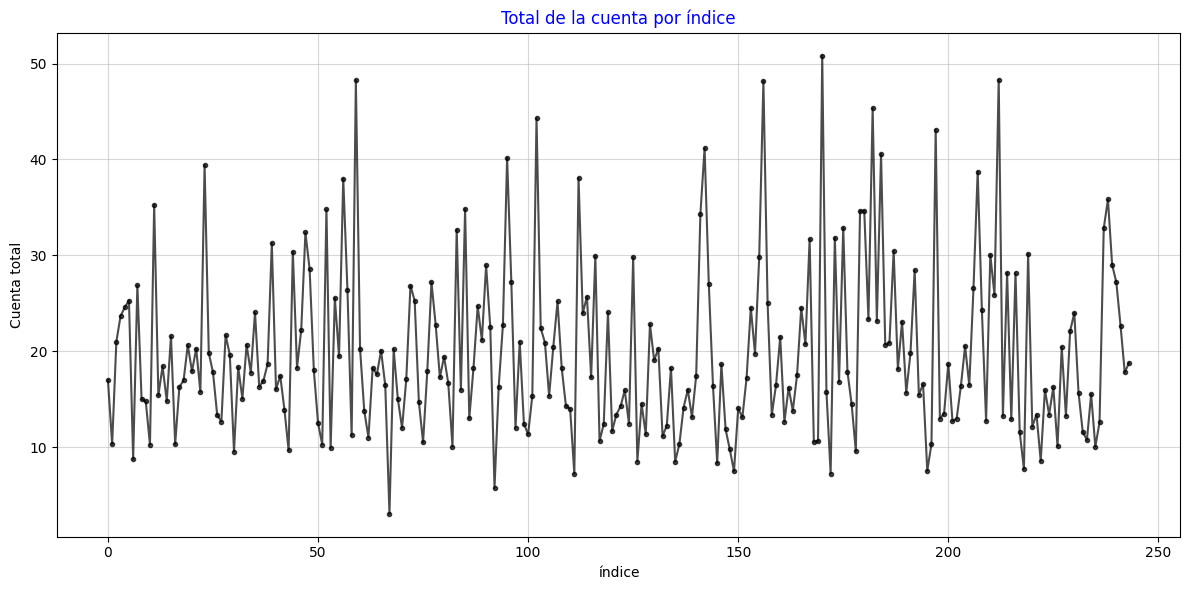

In [15]:
plt.figure(figsize = (12, 6))
plt.plot(tips['total_bill'], marker = '.', linestyle = '-', color = 'black', alpha = 0.7)
plt.title('Total de la cuenta por índice', color = 'blue', loc = 'center')
plt.xlabel('índice')
plt.ylabel('Cuenta total')
plt.grid(True, alpha = 0.5)
plt.tight_layout()

#### 📊 **Gráfico de barras**

In [16]:
mean_total_bill_per_day = tips.groupby('day')['total_bill'].mean()

In [17]:
mean_total_bill_per_day

,total_bill
day,
Thur,17.682742
Fri,17.151579
Sat,20.441379
Sun,21.410000


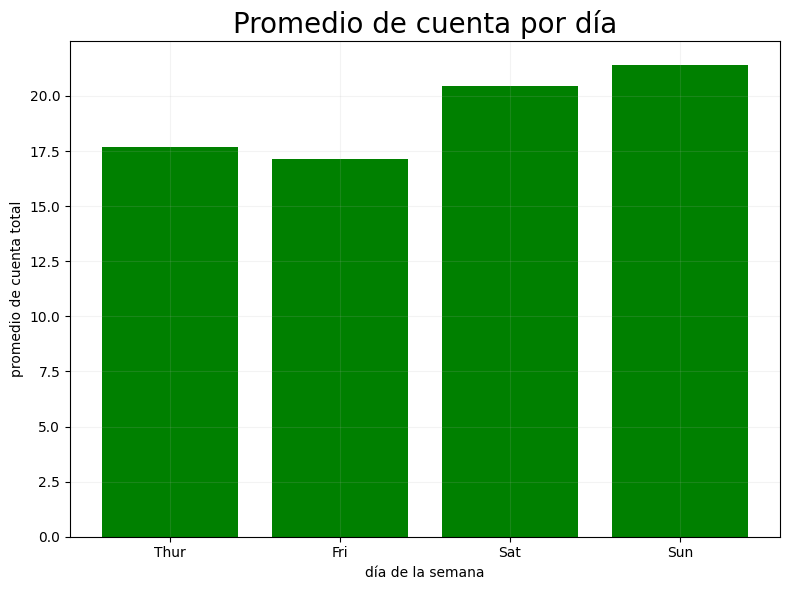

In [18]:
plt.figure(figsize = (8, 6))
plt.bar(mean_total_bill_per_day.index, mean_total_bill_per_day.values, color = 'green')
plt.title('Promedio de cuenta por día', fontsize = 20)
plt.xlabel('día de la semana')
plt.ylabel('promedio de cuenta total')
plt.grid(True, alpha = 0.15)
plt.tight_layout()

#### 🧶 **Gráfico de dispersión**

In [19]:
male_dinner_df = tips[(tips['sex'] == 'Male') & (tips['time'] == 'Dinner')]
male_lunch_df = tips[(tips['sex'] == 'Male') & (tips['time'] == 'Lunch')]
female_dinner_df = tips[(tips['sex'] == 'Female') & (tips['time'] == 'Dinner')]
female_lunch_df = tips[(tips['sex'] == 'Female') & (tips['time'] == 'Lunch')]

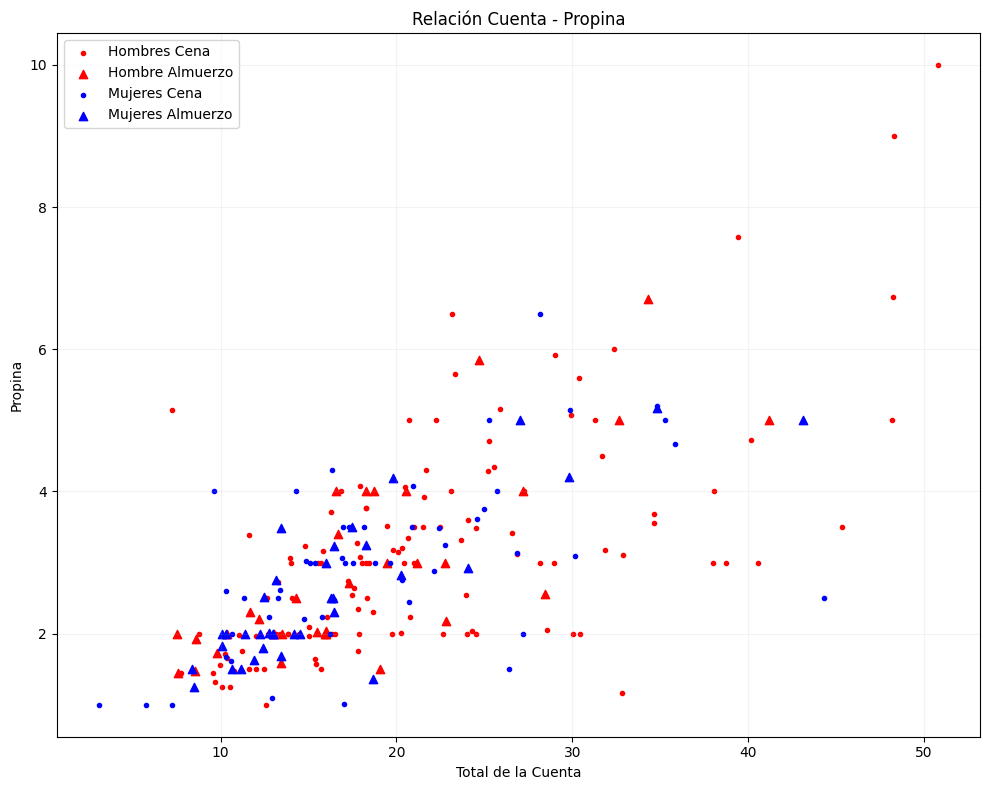

In [20]:
plt.figure(figsize = (10, 8))

# scatter_plot
plt.scatter(male_dinner_df['total_bill'], male_dinner_df['tip'], color = 'red', label = 'Hombres Cena', marker = '.')
plt.scatter(male_lunch_df['total_bill'], male_lunch_df['tip'], color = 'red', label = 'Hombre Almuerzo', marker = '^')
plt.scatter(female_dinner_df['total_bill'], female_dinner_df['tip'], color = 'blue', label = 'Mujeres Cena', marker = '.')
plt.scatter(female_lunch_df['total_bill'], female_lunch_df['tip'], color = 'blue', label = 'Mujeres Almuerzo', marker = '^')

# Convenciones y etiquetas
plt.title('Relación Cuenta - Propina')
plt.xlabel('Total de la Cuenta')
plt.ylabel('Propina')
plt.legend()
plt.grid(True, alpha = 0.15)
plt.tight_layout()

#### 📈 **Gráfico de líneas con `seaborn`**

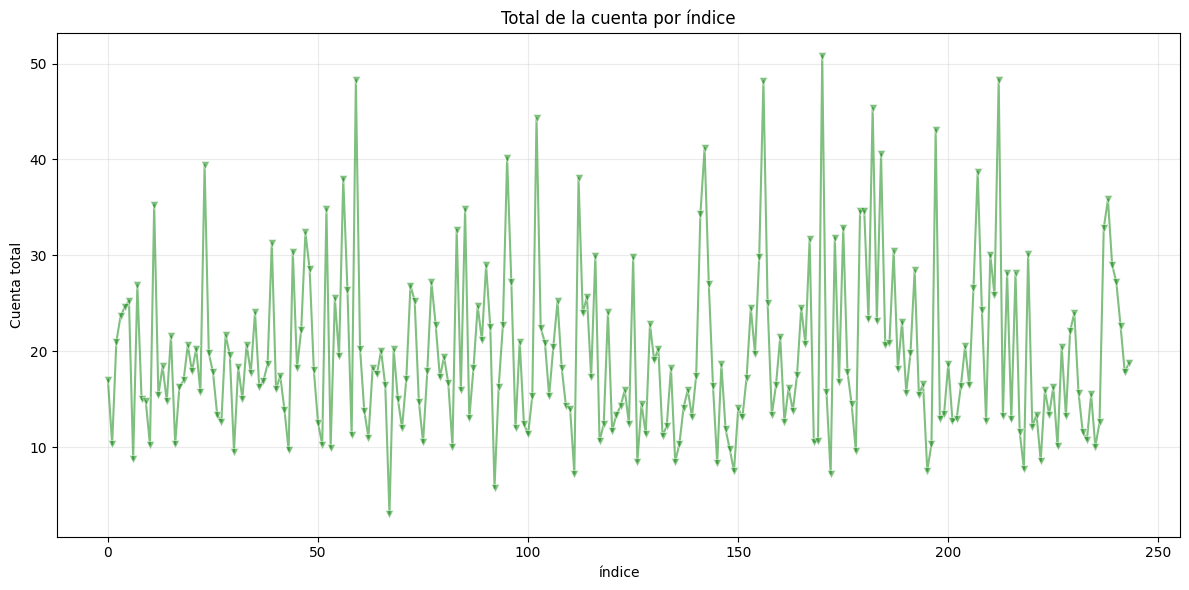

In [21]:
plt.figure(figsize = (12, 6))
sns.lineplot(data = tips, x = tips.index, y = 'total_bill', marker = 'v', color = 'green', linestyle = '-', alpha = 0.5)
plt.title('Total de la cuenta por índice')
plt.xlabel('índice')
plt.ylabel('Cuenta total')
plt.grid(True, alpha = 0.25)
plt.tight_layout()

#### 📊 **Gráfico de barras con `seaborn`**

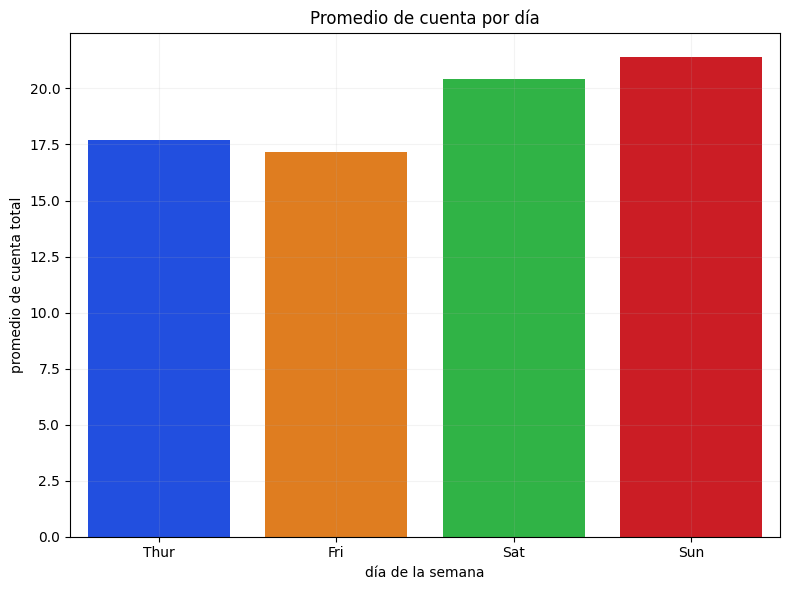

In [22]:
plt.figure(figsize = (8, 6))
sns.barplot(data = tips, x = 'day', y = 'total_bill', estimator = 'mean', palette = 'bright', ci = None)
plt.title('Promedio de cuenta por día')
plt.xlabel('día de la semana')
plt.ylabel('promedio de cuenta total')
plt.grid(True, alpha = 0.15)
plt.tight_layout()

#### 🎯 **Gráfico de dispersión con `seaborn`**

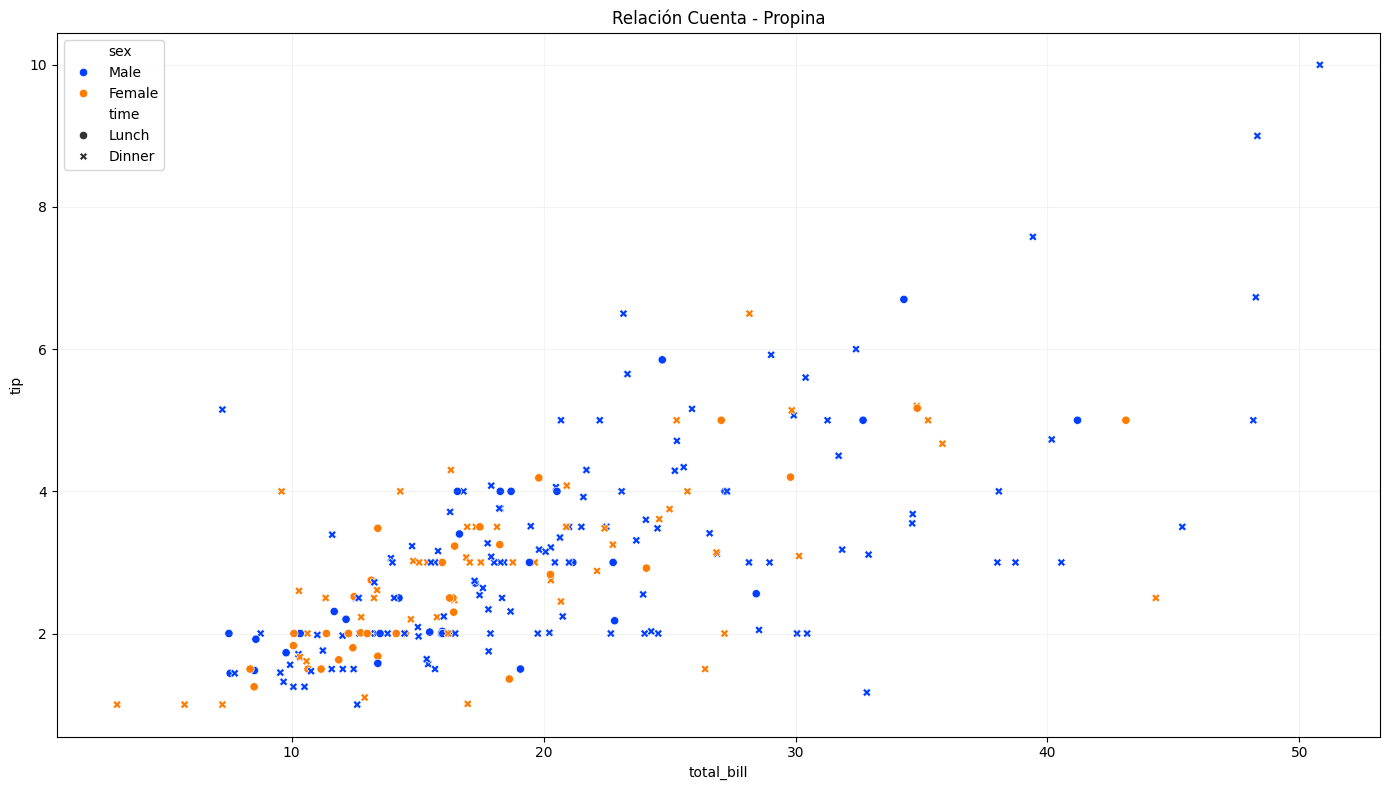

In [23]:
plt.figure(figsize = (14, 8))
#plt.scatter(tips[tips['sex']=='Male']['total_bill'], tips[tips['sex']=='Male']['tip'], color = 'red', label = 'Hombres', marker = '*')
#plt.scatter(tips[tips['sex']=='Female']['total_bill'], tips[tips['sex']=='Female']['tip'], color = 'blue', label = 'Mujeres', marker = 'd')
sns.scatterplot(data = tips, x = 'total_bill', y = 'tip', hue = 'sex', style = 'time', palette = 'bright')
plt.title('Relación Cuenta - Propina')
#plt.xlabel('Total de la Cuenta')
#plt.ylabel('Propina')
plt.legend()
plt.grid(True, alpha = 0.15)
plt.tight_layout()

### ⏩ **Visuales más avanzados**

#### 🍂 **Otros gráficos**

##### 🎻 **Gráfico de Violín**

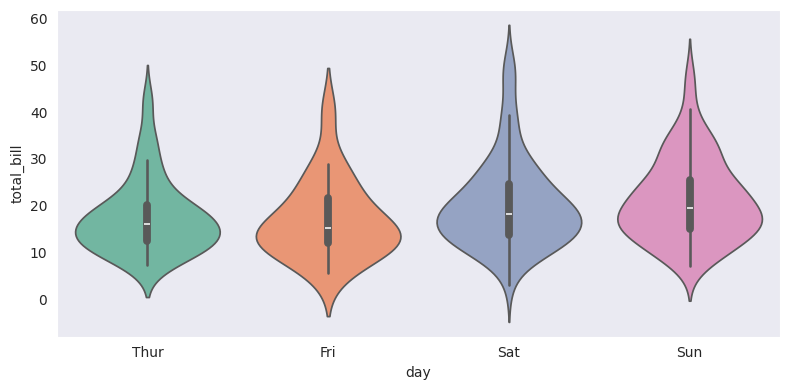

In [46]:
plt.figure(figsize = (8, 4))
sns.violinplot(data = tips, x = 'day', y = 'total_bill', palette='Set2')
plt.tight_layout()

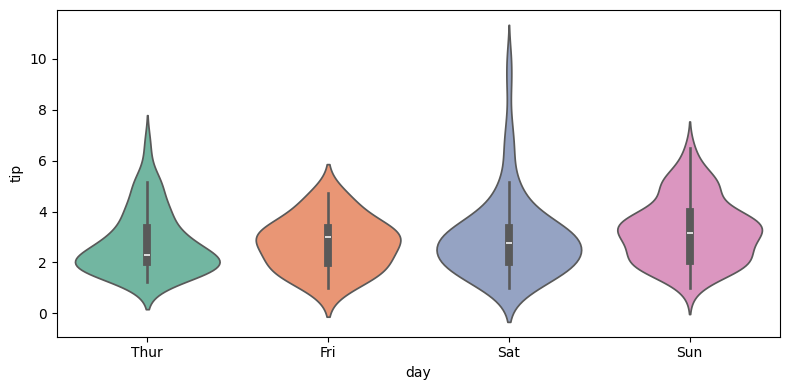

In [25]:
plt.figure(figsize = (8, 4))
sns.violinplot(data = tips, x = 'day', y = 'tip', palette='Set2')
plt.tight_layout()

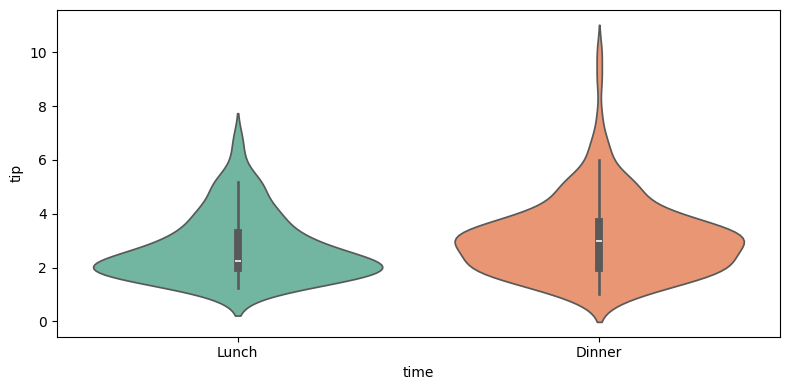

In [26]:
plt.figure(figsize = (8, 4))
sns.violinplot(data = tips, x = 'time', y = 'tip', palette='Set2')
plt.tight_layout()

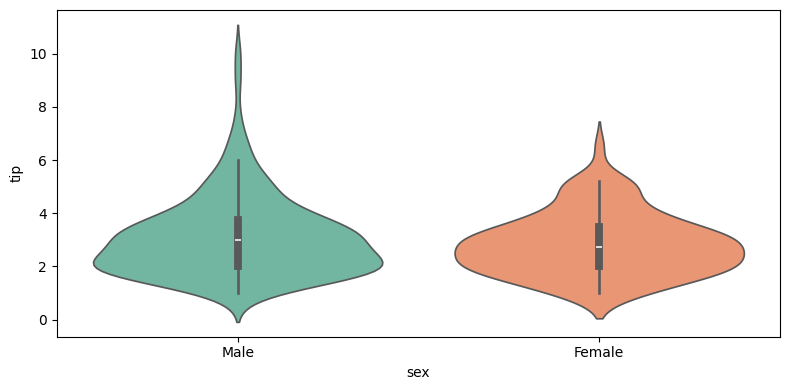

In [27]:
plt.figure(figsize = (8, 4))
sns.violinplot(data = tips, x = 'sex', y = 'tip', palette='Set2')
plt.tight_layout()

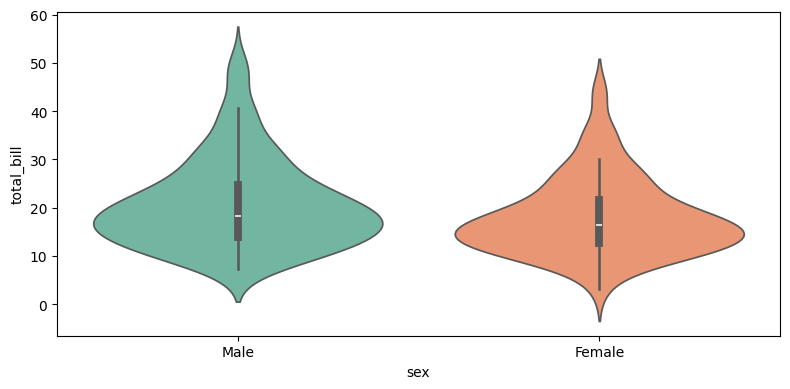

In [28]:
plt.figure(figsize = (8, 4))
sns.violinplot(data = tips, x = 'sex', y = 'total_bill', palette='Set2')
plt.tight_layout()

##### 📦 **Cajas y bigotes**

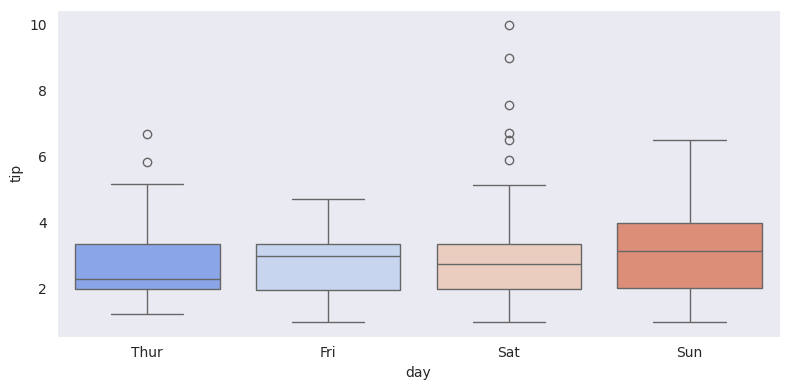

In [45]:
plt.figure(figsize = (8, 4))
sns.boxplot(data = tips, x = 'day', y = 'tip', palette='coolwarm')
plt.tight_layout()

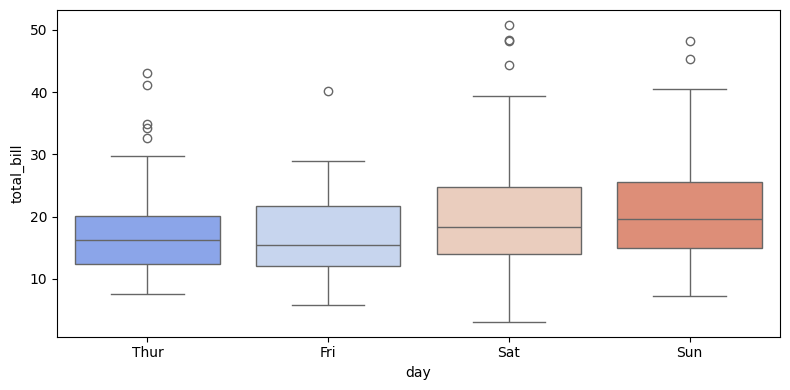

In [30]:
plt.figure(figsize = (8, 4))
sns.boxplot(data = tips, x = 'day', y = 'total_bill', palette='coolwarm')
plt.tight_layout()

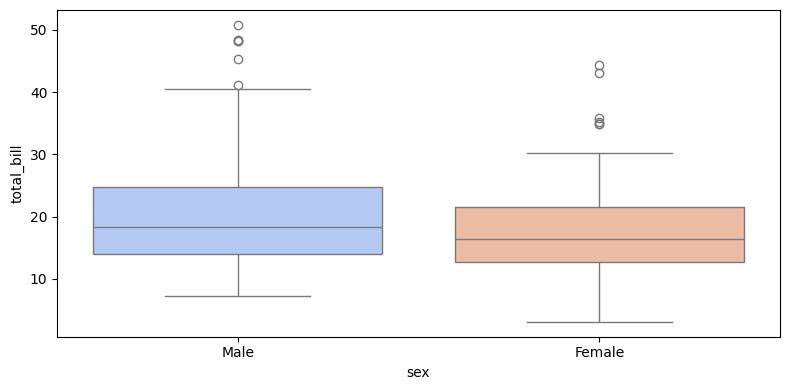

In [31]:
plt.figure(figsize = (8, 4))
sns.boxplot(data = tips, x = 'sex', y = 'total_bill', palette='coolwarm')
plt.tight_layout()

##### 🧊 **Histograma**

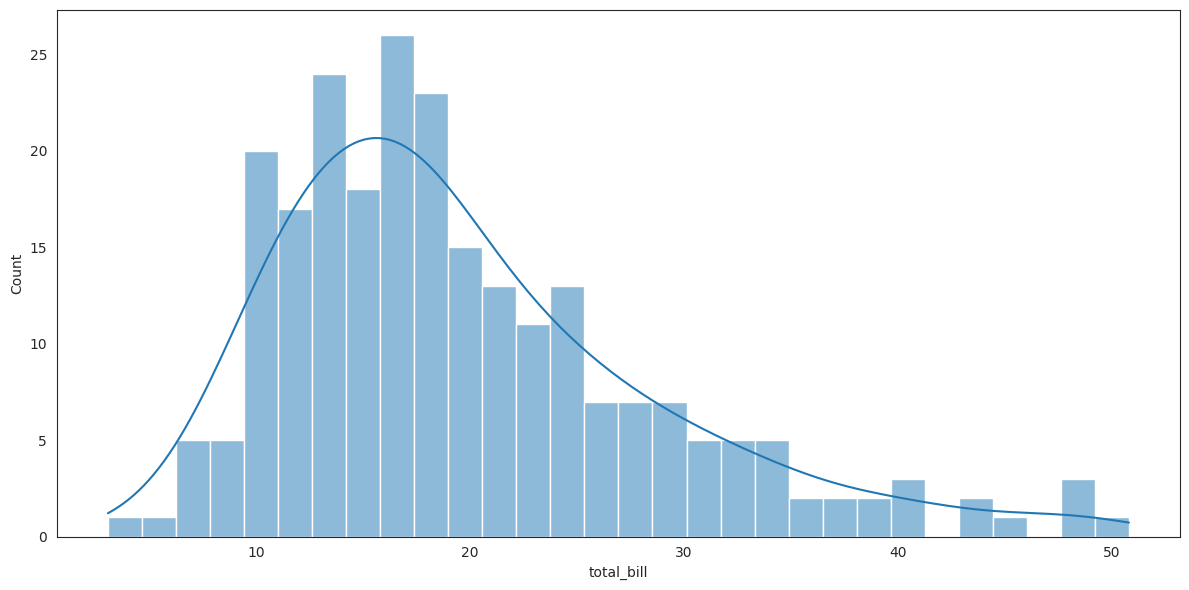

In [48]:
sns.set_style('white')

plt.figure(figsize = (12, 6))
sns.histplot(data = tips, x = 'total_bill', bins = 30, kde=True)
plt.tight_layout()

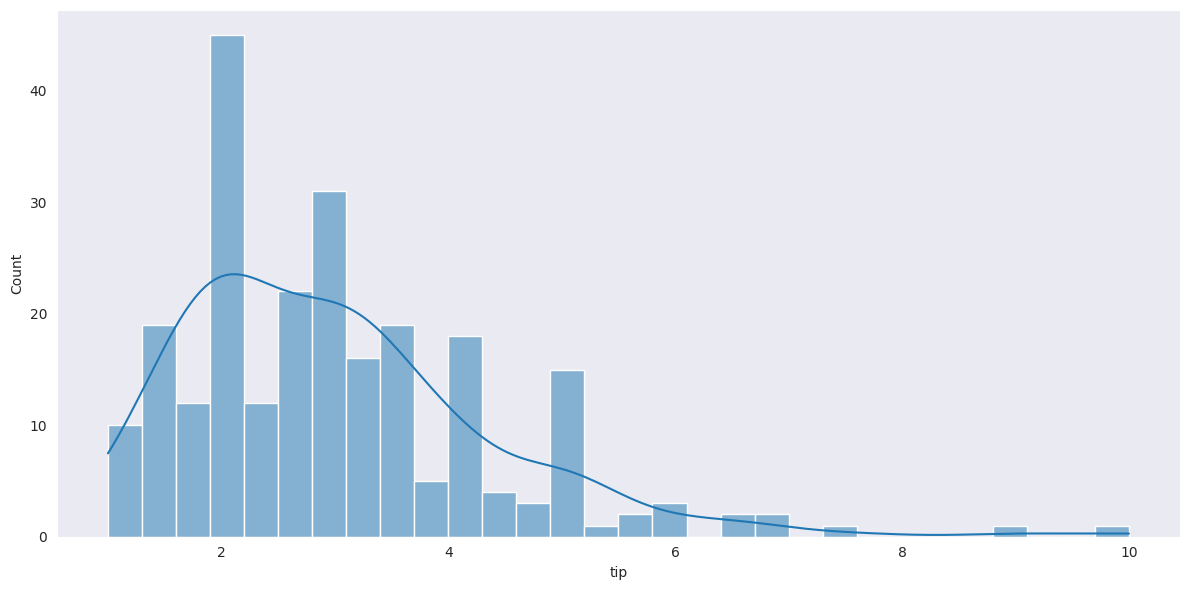

In [33]:
sns.set_style('dark')

plt.figure(figsize = (12, 6))
sns.histplot(data = tips, x = 'tip', bins = 30, kde=True)
plt.tight_layout()

#### 🔄 **Relaciones y Tendencias: Regresión Visual con Seaborn**

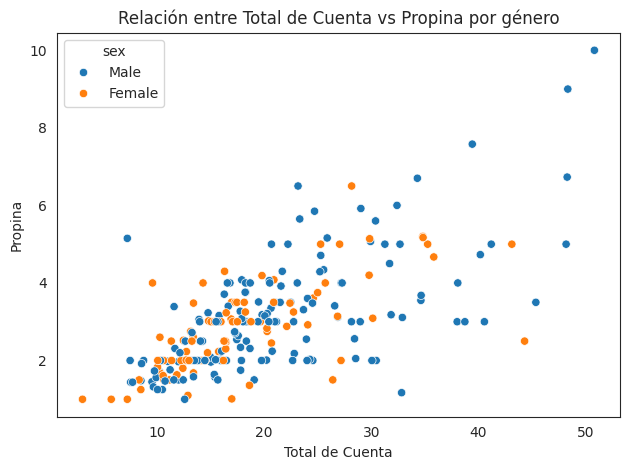

In [49]:
sns.scatterplot(data = tips, x = 'total_bill', y = 'tip', hue = 'sex')
plt.title('Relación entre Total de Cuenta vs Propina por género')
plt.xlabel('Total de Cuenta')
plt.ylabel('Propina')
plt.tight_layout()

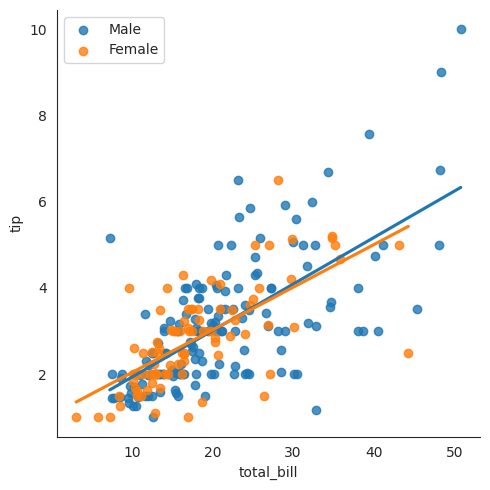

In [50]:
sns.lmplot(data = tips, x = 'total_bill', y = 'tip', hue = 'sex', ci = None, legend = None) # lm: linear model
plt.legend(loc = 'upper left')
plt.tight_layout()

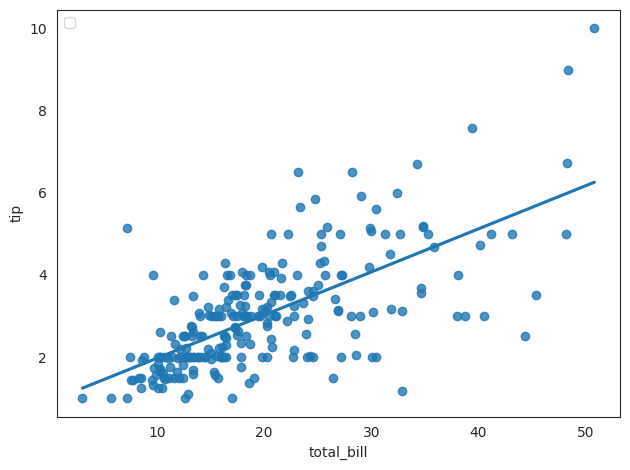

In [58]:
sns.regplot(data = tips, x = 'total_bill', y = 'tip', ci = None, order = 1)
plt.legend(loc = 'upper left')
plt.tight_layout()

#### 🗾 **Mapa de calor**

In [59]:
tips['tip_pct'] = tips['tip'] / tips['total_bill']

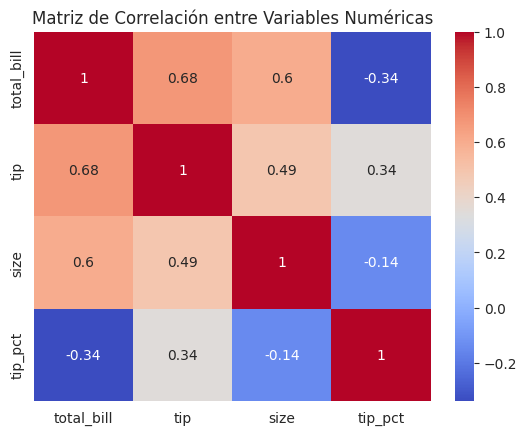

In [60]:
# Matriz de correlación
corr = tips[['total_bill', 'tip', 'size', 'tip_pct']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matriz de Correlación entre Variables Numéricas")
plt.show()

#### 🔲 **Facetado**

Text(0.5, 1.05, 'Distribución de % Propina por Día y Sexo')

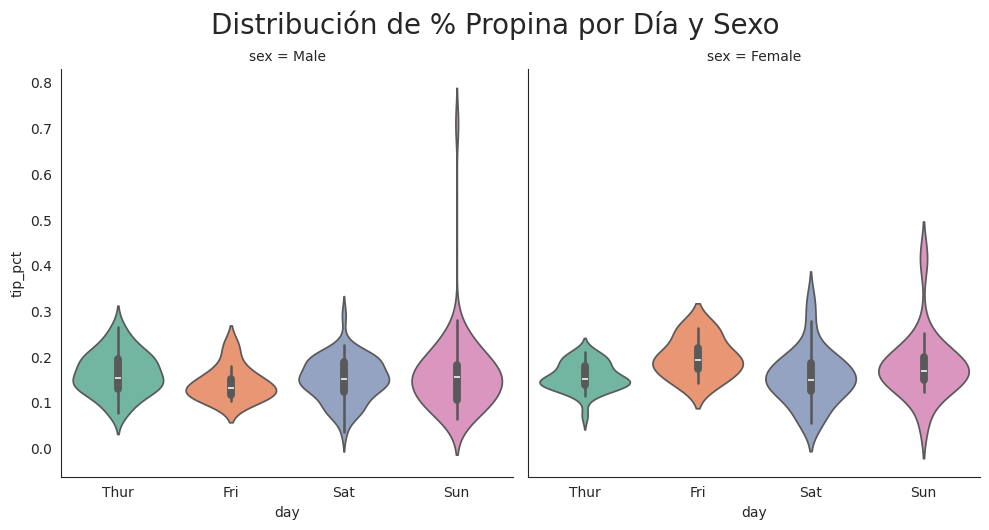

In [61]:
# Mostramos cómo varía el porcentaje de propina por día y sexo
tips['tip_pct'] = tips['tip'] / tips['total_bill']

g = sns.catplot(
    data=tips,
    x='day',
    y='tip_pct',
    col='sex',
    kind='violin',
    #height=5,
    #aspect=1,
    palette='Set2'
)
g.fig.suptitle('Distribución de % Propina por Día y Sexo', fontsize=20, y=1.05)

### 👥 **Subplots con Matplotlib**

(<Figure size 1800x900 with 6 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >]], dtype=object))

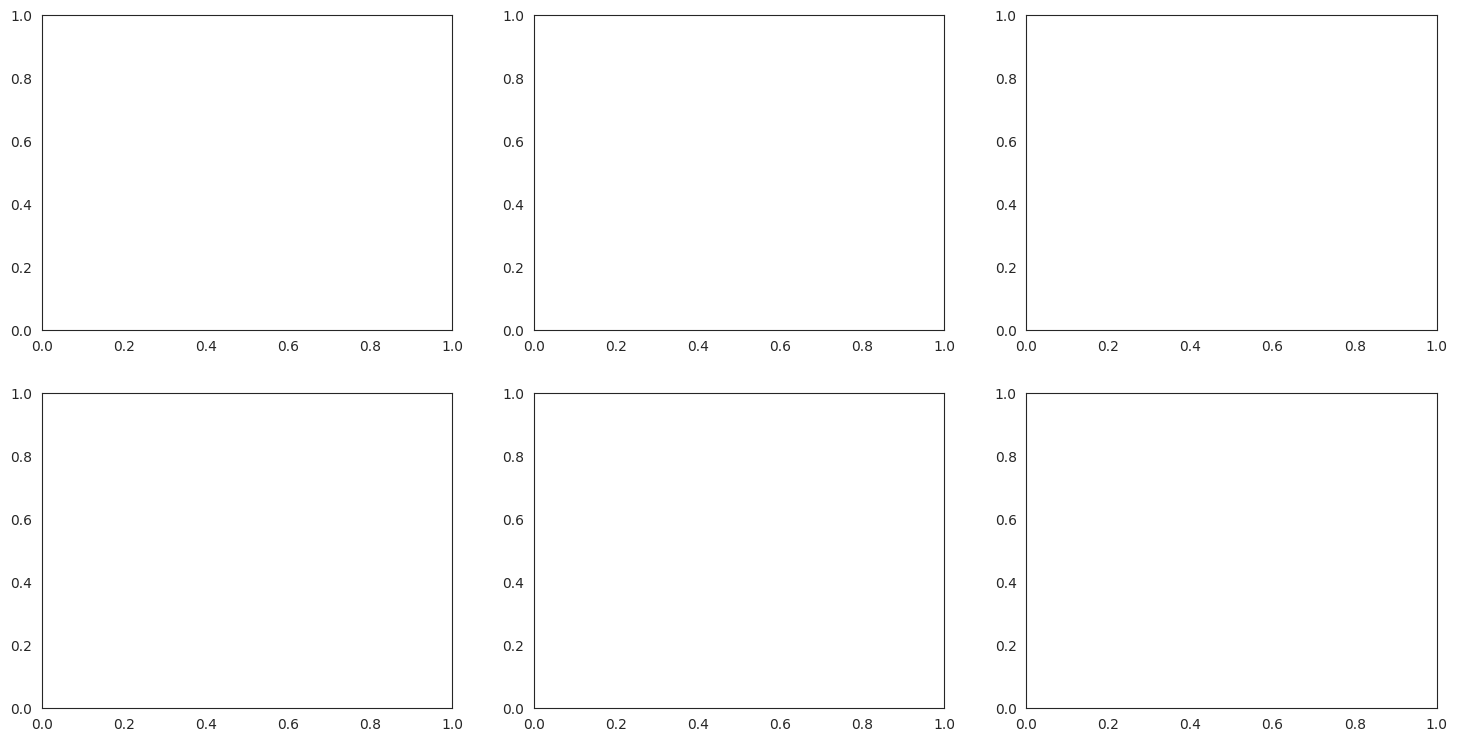

In [62]:
plt.subplots(2, 3, figsize=(18, 9))

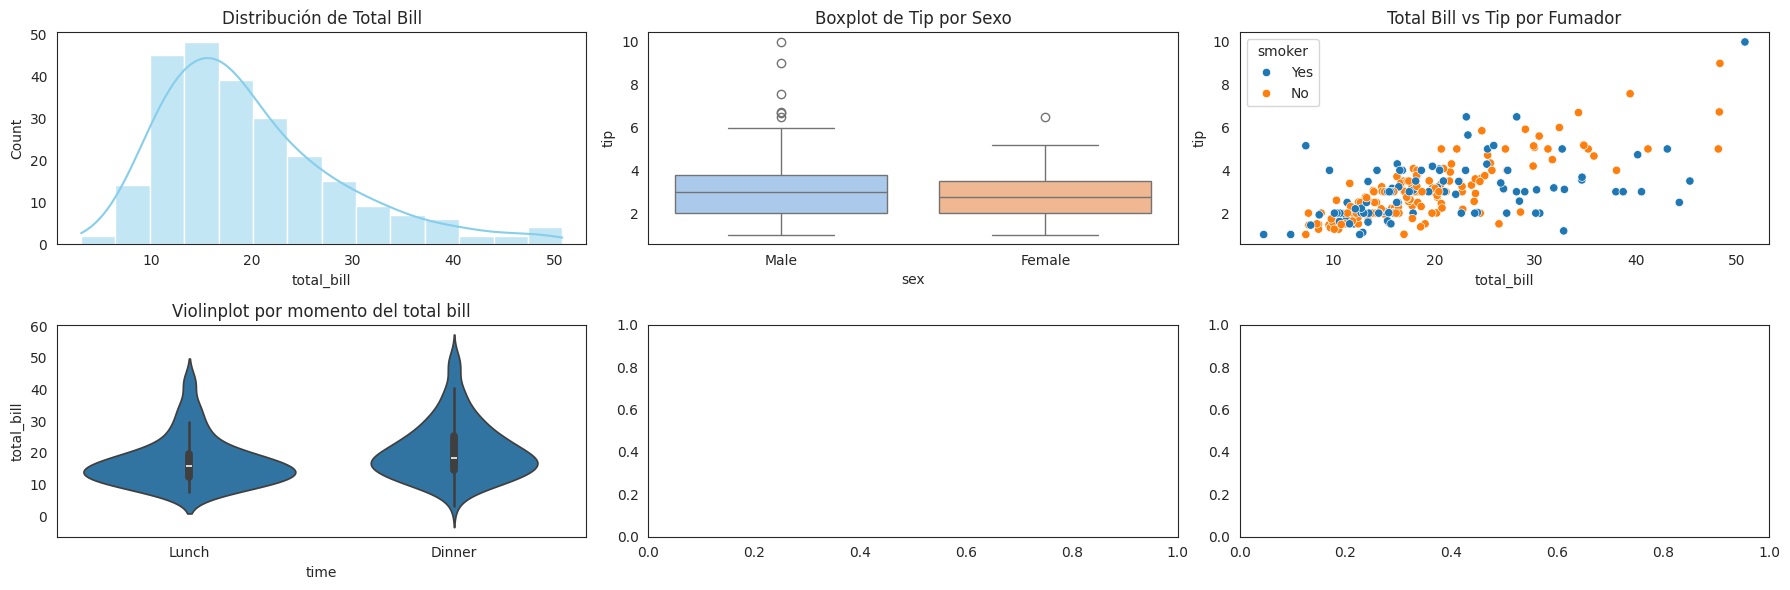

In [83]:
# Mostramos tres gráficos en una misma figura: histograma, boxplot y scatterplot
fig, axs = plt.subplots(2, 3, figsize=(18, 6))  # 1 fila, 3 columnas

# Histograma de total_bill
sns.histplot(tips['total_bill'], ax=axs[0][0], color='skyblue', kde=True)
axs[0][0].set_title('Distribución de Total Bill')

# Boxplot de propinas por sexo
sns.boxplot(data=tips, x='sex', y='tip', ax=axs[0][1], palette='pastel')
axs[0][1].set_title('Boxplot de Tip por Sexo')

# Scatterplot
sns.scatterplot(data=tips, x='total_bill', y='tip', ax=axs[0][2], hue='smoker')
axs[0][2].set_title('Total Bill vs Tip por Fumador')

# Violinplot
sns.violinplot(data=tips, x='time', y='total_bill', ax=axs[1][0])
axs[1][0].set_title('Violinplot por momento del total bill')

plt.tight_layout()

### 📝 **Personalización de etiquetas, fuentes y anotaciones**

In [84]:
max_tip = tips.loc[tips['tip'].idxmax()]

In [91]:
max_tip

,170
total_bill,50.81
tip,10.0
sex,Male
smoker,Yes
day,Sat
time,Dinner
size,3
tip_pct,0.196812


In [85]:
print(f"Propina más alta:\n${max_tip['tip']}")

Propina más alta:
$10.0


In [92]:
max_tip_pct = tips.loc[tips['tip_pct'].idxmax()]

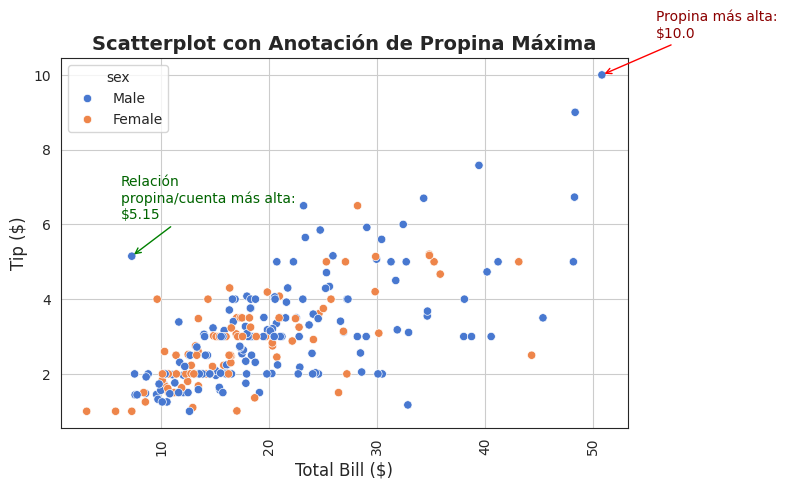

In [97]:
# Destacamos el punto con la propina más alta
plt.figure(figsize=(8, 5))
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='sex', palette='muted')

# Encontrar el punto con mayor propina
max_tip = tips.loc[tips['tip'].idxmax()]

# Anotar en el gráfico
plt.annotate(
    f"Propina más alta:\n${max_tip['tip']}",
    xy=(max_tip['total_bill'], max_tip['tip']),
    xytext=(max_tip['total_bill'] + 5, max_tip['tip'] + 1),
    arrowprops=dict(arrowstyle="->", color='red'),
    fontsize=10,
    color='darkred'
)

# Anotar en el gráfico
plt.annotate(
    f"Relación\npropina/cuenta más alta:\n${max_tip_pct['tip']}",
    xy=(max_tip_pct['total_bill'], max_tip_pct['tip']),
    xytext=(max_tip_pct['total_bill']-1, max_tip_pct['tip'] + 1),
    arrowprops=dict(arrowstyle="->", color='green'),
    fontsize=10,
    color='darkgreen'
)

plt.title('Scatterplot con Anotación de Propina Máxima', fontsize=14, fontweight='bold')
plt.xlabel('Total Bill ($)', fontsize=12)
plt.ylabel('Tip ($)', fontsize=12)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.grid(True)
plt.tight_layout()
plt.show()

### 📊 **Gráficos estadísticos adicionales**

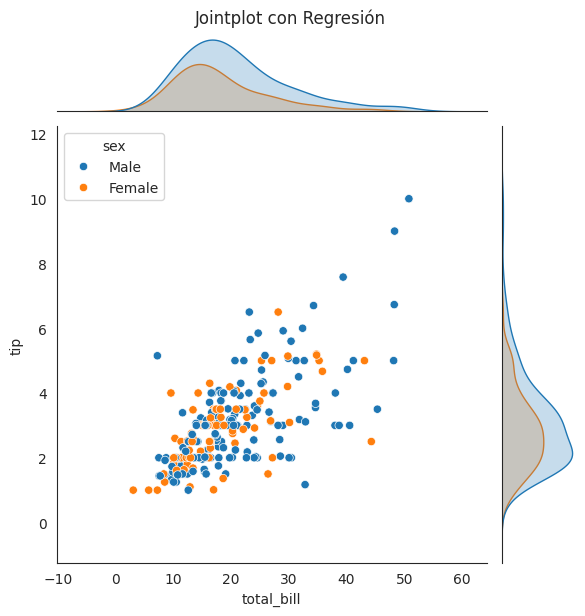

In [98]:
# Jointplot: combinación de histograma + scatter + regresión
sns.jointplot(data=tips, x='total_bill', y='tip', height=6, color='green', hue = 'sex')
plt.suptitle("Jointplot con Regresión", y=1.02)
plt.show()

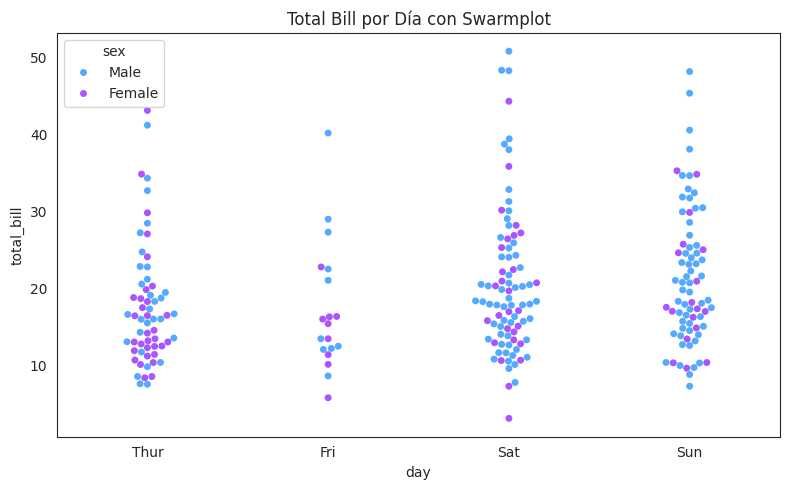

In [89]:
# Swarmplot: visualización de cada punto con separación
plt.figure(figsize=(8, 5))
sns.swarmplot(data=tips, x='day', y='total_bill', hue='sex', palette='cool')
plt.title("Total Bill por Día con Swarmplot")
plt.tight_layout()
plt.show()